# IMPORT PACKAGES

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import time
from memory_profiler import memory_usage

c:\Users\ARRF\Desktop\Maruthi\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SEED

In [2]:
# Set a seed value
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)

# CUDA

In [3]:
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

True
Using device: cuda



# READ TSP

In [4]:
def read_tsp_file(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    city_coords = []
    for line in lines:
        if line.startswith('EOF'):
            break
        if line[0].isdigit():
            _, x, y = line.strip().split()
            city_coords.append((float(x), float(y)))
    
    n = len(city_coords)
    distance_matrix = torch.zeros((n, n), device=device)
    for i in range(n):
        for j in range(n):
            if i != j:
                distance = math.sqrt((city_coords[i][0] - city_coords[j][0])**2 + (city_coords[i][1] - city_coords[j][1])**2)
                distance_matrix[i][j] = distance
    
    return distance_matrix, city_coords

# BFS

In [5]:
def bfs(distance_matrix, max_iterations):
    n = distance_matrix.shape[0]
    start_city = 0
    queue = [(start_city, [start_city], 0)]  # (current_city, path_taken, total_distance)
    min_cost = float('inf')
    best_path = None
    iterations = 0
    
    while queue and iterations < max_iterations:
        current_city, path, distance = queue.pop(0)
        
        if len(path) == n:
            total_distance = distance + distance_matrix[current_city][start_city].item()
            if total_distance < min_cost:
                min_cost = total_distance
                best_path = path + [start_city]
            continue
        
        for next_city in range(n):
            if next_city not in path:
                new_distance = distance + distance_matrix[current_city][next_city].item()
                new_path = path + [next_city]
                queue.append((next_city, new_path, new_distance))
        
        iterations += 1
    
    return min_cost, best_path

# PLOT PATH

In [6]:
def plot_tsp_path(city_coords, path):
    x = [coord[0] for coord in city_coords]
    y = [coord[1] for coord in city_coords]
    
    plt.scatter(x, y, c='blue')

    for i in range(len(path) - 1):
        plt.plot([x[path[i]], x[path[i+1]]], [y[path[i]], y[path[i+1]]], c='red')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('TSP Path with BFS')
    plt.show()

# DS1

Optimal Cost: inf
Optimal Path: None
Execution Time: 2110.6721651554108 seconds
Memory Usage: 1385.609375 MiB


TypeError: object of type 'NoneType' has no len()

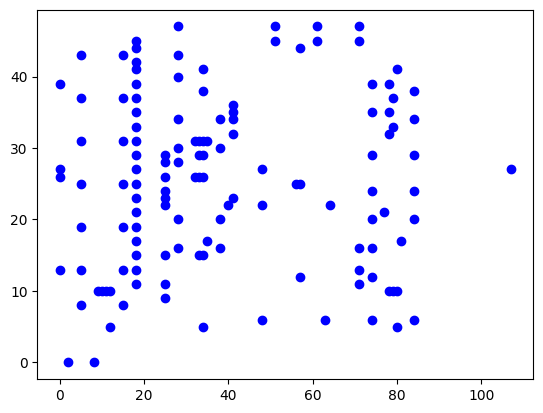

In [9]:
import time
from memory_profiler import memory_usage

filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS1//DS1.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = bfs(distance_matrix, max_iterations=100000)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)

# DS2

Optimal Cost: inf
Optimal Path: None
Execution Time: 2228.3448588848114 seconds
Memory Usage: 1387.71875 MiB


TypeError: object of type 'NoneType' has no len()

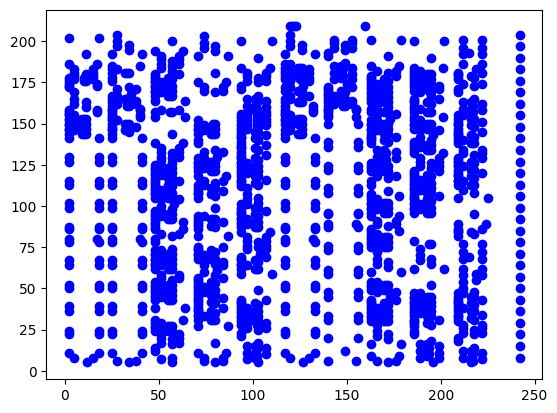

In [10]:

filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS2//DS2.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = bfs(distance_matrix, max_iterations=10000)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)

# DS3

Optimal Cost: inf
Optimal Path: None
Execution Time: 7246.179562568665 seconds
Memory Usage: 1392.234375 MiB


TypeError: object of type 'NoneType' has no len()

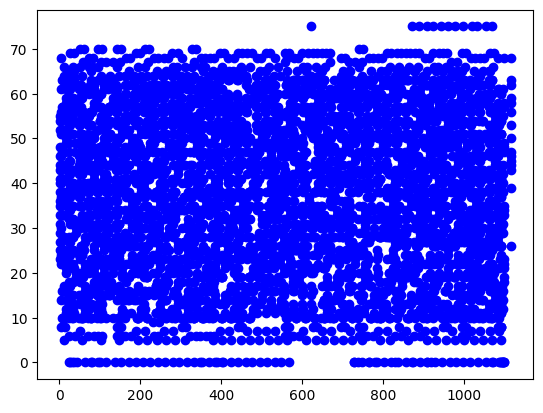

In [11]:

filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS3//DS3.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = bfs(distance_matrix, max_iterations=10000)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)